In [2]:
import pandas as pd

In [3]:
from sklearn.datasets import fetch_california_housing
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = fetch_california_housing()

In [5]:
dataset = pd.DataFrame(df.data)

In [6]:
dataset.columns = df.feature_names

In [7]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [8]:
## Independent features and dependent features

In [9]:
X = dataset

In [10]:
y = df.target

In [11]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [12]:
## train test split

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.30, random_state =42)

In [15]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
7061,4.1312,35.0,5.882353,0.975490,1218.0,2.985294,33.93,-118.02
14689,2.8631,20.0,4.401210,1.076613,999.0,2.014113,32.79,-117.09
17323,4.2026,24.0,5.617544,0.989474,731.0,2.564912,34.59,-120.14
10056,3.1094,14.0,5.869565,1.094203,302.0,2.188406,39.26,-121.00
15750,3.3068,52.0,4.801205,1.066265,1526.0,2.298193,37.77,-122.45
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [16]:
## standardizing the dataset
from sklearn.preprocessing import StandardScaler

In [17]:
sc = StandardScaler()

In [18]:
X_train = sc.fit_transform(X_train)

In [19]:
X_test = sc.transform(X_test)

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
## cross validation

In [22]:
from sklearn.model_selection import cross_val_score

In [23]:
regression = LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

In [24]:
mse = cross_val_score(regression, X_train,y_train,scoring ='neg_mean_squared_error',cv=5)

In [25]:
np.mean(mse)

-0.5268253746355748

In [26]:
## prediction

In [27]:
reg_pred = regression.predict(X_test)

In [28]:
reg_pred

array([0.72604907, 1.76743383, 2.71092161, ..., 2.07465531, 1.57371395,
       1.82744133])

In [29]:
import seaborn as sns

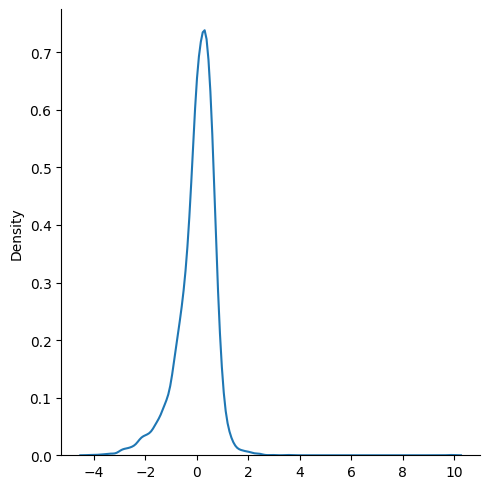

In [30]:
sns.displot(reg_pred-y_test, kind ='kde')

In [31]:
from sklearn.metrics import r2_score

In [32]:
score = r2_score(reg_pred,y_test)

In [33]:
score

0.3451339380943985

In [34]:
#### Ridge Regression Algorithm

In [35]:
from sklearn.linear_model import Ridge

In [36]:
from sklearn.model_selection import GridSearchCV

In [37]:
ridge_regressor = Ridge()

In [38]:
ridge_regressor

Ridge()

In [39]:
parameters = {'alpha' : [1,2,5,10,20,30,40,50,60,70,80,90]}

In [40]:
ridgeCV = GridSearchCV(ridge_regressor,parameters,scoring ='neg_mean_squared_error',cv = 5)

In [41]:
ridgeCV.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [42]:
print(ridgeCV.best_params_)

{'alpha': 5}


In [43]:
print(ridgeCV.best_score_)

-0.5268179966861515


In [44]:
ridge_pred=ridgeCV.predict(X_test)

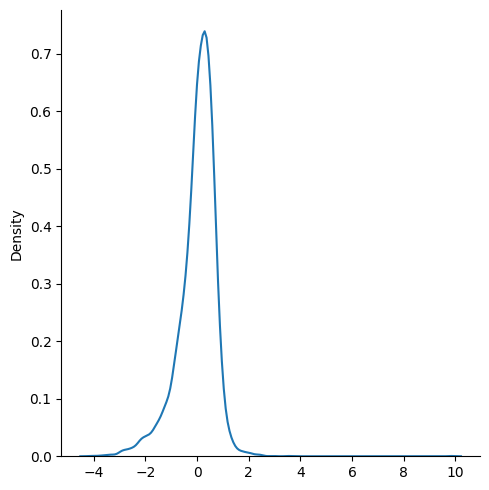

In [45]:
sns.displot(ridge_pred-y_test, kind ='kde')

In [46]:
score = r2_score(ridge_pred,y_test)

In [47]:
score

0.34383945441404373

In [48]:
### laso regression

In [49]:
from sklearn.linear_model import Lasso

In [50]:
lasso = Lasso()

In [51]:
parameters = {'alpha' : [1,2,5,10,20,30,40,50,60,70,80,90]}
lassoCV = GridSearchCV(lasso,parameters,scoring ='neg_mean_squared_error',cv = 5)
lassoCV.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [52]:
print(lassoCV.best_score_)

-1.3400019579636542


In [53]:
print(lassoCV.best_params_)

{'alpha': 1}


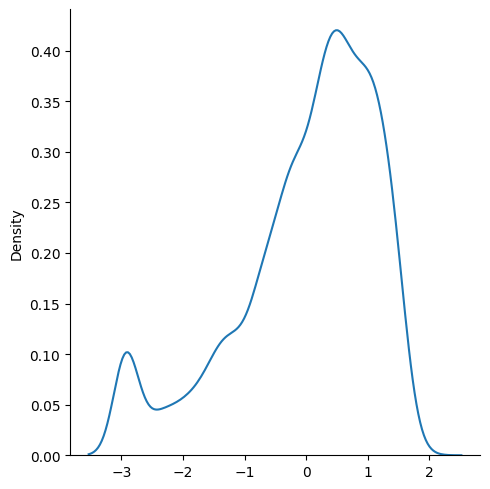

In [54]:
lasso_pred=lassoCV.predict(X_test)
sns.displot(lasso_pred-y_test, kind ='kde')

In [55]:
score = r2_score(lasso_pred,y_test)

In [56]:
score

0.0

In [57]:
df_exe = pd.read_csv("canada_per_capita_income.csv")

In [58]:
df_exe

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583
5,1975,5998.144346
6,1976,7062.131392
7,1977,7100.126170
8,1978,7247.967035
9,1979,7602.912681


In [59]:
from sklearn.linear_model import LinearRegression

In [60]:
reg = LinearRegression()

In [62]:
reg.fit(df_exe[['year']], df_exe['per capita income (US$)'])

LinearRegression()

In [65]:
reg.predict([[2026]])

D:\Python\python\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([46259.48454575])

In [67]:
reg.score(df_exe[['year']], df_exe['per capita income (US$)'])

0.890916917957032

In [68]:
%matplotlib.inline

UsageError: Line magic function `%matplotlib.inline` not found.


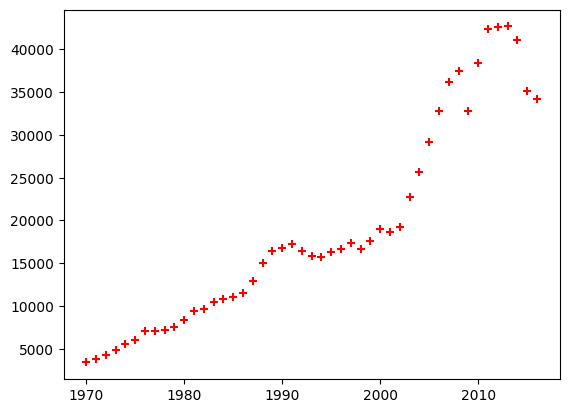

In [70]:
plt.scatter(df_exe.year, df_exe['per capita income (US$)'], color = 'red', marker = '+')

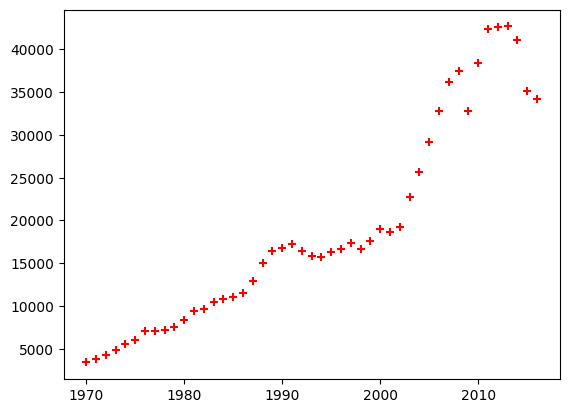

In [71]:
plt.scatter(df_exe.year, df_exe['per capita income (US$)'], color = 'red', marker = '+')

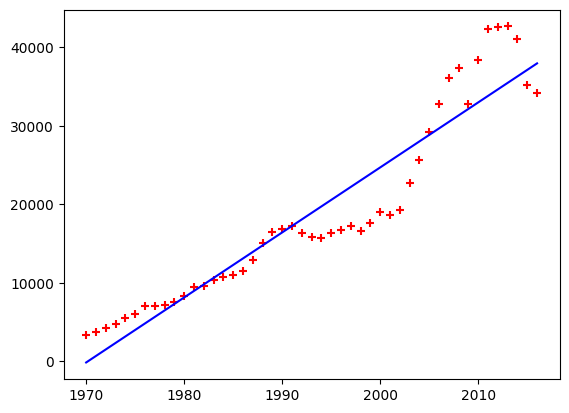

In [73]:
plt.scatter(df_exe.year, df_exe['per capita income (US$)'], color = 'red', marker = '+')
plt.plot(df_exe.year, reg.predict(df_exe[['year']]), color = 'blue')